# Домашнее задание - линейная регрессия

### Работа с признаками (8 баллов)

Скачайте датасет из материалов к уроку или по ссылке https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv 


Описание признаков:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж 
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного

Ответ:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

Обработайте пропущенные значения и примените написанные функции onehot_encode() и minmax_scale().

**Подсказка**: маску для категориальных признаков можно сделать фильтром cat_features_mask = (df.dtypes == "object").values

In [ ]:
# импортирум все необходимое
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
#"примените написанные функции" не совсем понял, но на всякий случай буду использовать функции из прошлых заданий
def onehot_encoding(x: np.ndarray):
    L = len(x)
    x1 = np.sort(x)
    w = {}
    N = 0
    for j in x1:
        if j not in w:
            w[j] = N
            N += 1

    f = np.eye(N, N, dtype = np.float32)
    Q = np.empty([L, N], np.float32)
    for j, i in enumerate(x):
        Q[j] = f[w[i]]

    return Q


def minmax_scale(X: np.ndarray):
    if len(X) <= 1:
        return np.zeros_like(X, np.float32)
    Mi = X.min(axis=0)
    Ma = X.max(axis=0)
    return (X - Mi) / (Ma - Mi)




def get_claim_info(value_name, print_info = True): # показывает долю страховых выплат по каждому значению категориального параметра
    global df
    VU = df[value_name].unique()
    HH = {}
    for v in VU:
        s = len(df[(df[value_name] == v) & (df['Claim'] == 'Yes')])/len(df[df[value_name]==v])
        if print_info:print(f"{v} : {100*s}%")
        HH[v] = s

    return HH

def show_all(print_info = True):
    q = list(df.dtypes[df.dtypes == "object"].keys())
    q.remove('Claim')
    for g in q:
        print(f"============ {g} ==================")
        HH = get_claim_info(g)
        plt.pie(HH.values(), labels = HH.keys())
        plt.show()


#### Обрабатываю NaN

In [ ]:
df = pd.read_csv("travel insurance.csv")

In [ ]:
# первым делом посмотрим сколько промущенных значений встречается в данных
Nans = df[df.isnull().any(axis=1)] # берем все строки в которых есть хотя бы 1 Nan
RowCount = df.shape[0]
NaNRowCount = Nans.shape[0]

NaNRowCount/RowCount

0.7122982661150239

In [ ]:
# теперь посмотрим сколько Nan - ов в каждой коллонке
df.isnull().sum(axis=0)

Agency                      0
Agency Type                 0
Distribution Channel        0
Product Name                0
Claim                       0
Duration                    0
Destination                 0
Net Sales                   0
Commision (in value)        0
Gender                  45107
Age                         0
dtype: int64

In [ ]:
# Как можно заметить все Наны содержатся в колонке Gender
# 71% данных в этой колонке неизвестны, будет разумно избавиться от неё

df = df.drop(columns='Gender', axis=1)
df

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,41
...,...,...,...,...,...,...,...,...,...,...
63321,JZI,Airlines,Online,Basic Plan,No,111,JAPAN,35.0,12.25,31
63322,JZI,Airlines,Online,Basic Plan,No,58,CHINA,40.0,14.00,40
63323,JZI,Airlines,Online,Basic Plan,No,2,MALAYSIA,18.0,6.30,57
63324,JZI,Airlines,Online,Basic Plan,No,3,VIET NAM,18.0,6.30,63


#### Подробный анализ и подготовка датасета

Подробный анализ и подготовка датасета часто помогают улучшить качество модели. Ниже представлено несколько идей преобразований. Вы можете применить одно или несколько из этих преобразований (а можете не применять), чтобы помочь будущей модели. 

1. Посмотрите на количественные признаки. Возможно, в некоторых признаках есть выбросы - значения, которые сильно выбиваются. Такие значения полезно удалять. Советуем присмотреться к колонке Duration)

2. Можно заметить, что one hot encoding сильно раздувает количество столбцов. Радикальное решение - можно попробовать выбросить все категориальные признаки из датасета.

3. Если все-таки оставляете категориальные признаки, то подумайте, как уменьшить количество столбцов после one hot encoding. Признаки с большим количеством значений (Duration - 149! разных стран) можно удалить или попробовать сгруппировать некоторые значения.

4. Downsampling. Датасет достаточно большой, разница в классах огромная. Можно уменьшить число наблюдений с частым ответом.

##### DOWNSAMPLING

Прежде стоит посмотреть соотношения Claim для True/False

In [ ]:
C = len(df['Claim'])
print(f'True: {len(df[df["Claim"] == "Yes"])}')
print(f"False: {len(df[df['Claim'] == 'No'])}")
print(f'True/C: {100*len(df[df["Claim"] == "Yes"])/C}%')
print(f"False/C: {100*len(df[df['Claim'] == 'No'])/C}%")
print(f"True/False: {100*len(df[df['Claim'] == 'Yes'])/len(df[df['Claim'] == 'No'])}%")

True: 927
False: 62399
True/C: 1.4638537093768753%
False/C: 98.53614629062312%
True/False: 1.485600730780942%


В данных и в правду большенство значений для Claim = 0, по этому стоит убрать (62399 - 927 = 61472) строк со значением Claim = 0

Строки выберем случайно, что бы по минимуму повлиять на зависимости

до
============ Agency ==================
CBH : 0.9900990099009901%
CWT : 1.0023310023310024%
JZI : 0.48980881655869807%
KML : 2.0408163265306123%
EPX : 0.5552549901762579%
C2B : 6.616668682714407%
JWT : 0.5340453938584779%
RAB : 0.13793103448275862%
SSI : 0.6628787878787878%
ART : 0.3021148036253776%
CSR : 1.1627906976744187%
CCR : 1.5463917525773196%
ADM : 0.0%
LWC : 5.2249637155297535%
TTW : 4.081632653061225%
TST : 0.3787878787878788%


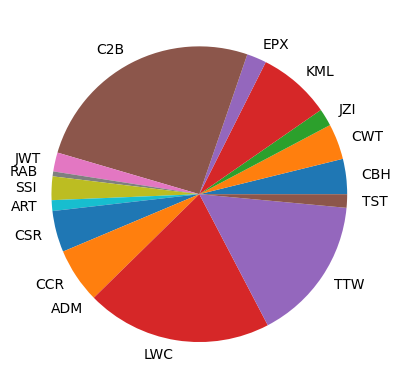

============ Agency Type ==================
Travel Agency : 0.7325208746648062%
Airlines : 3.3854614194878847%


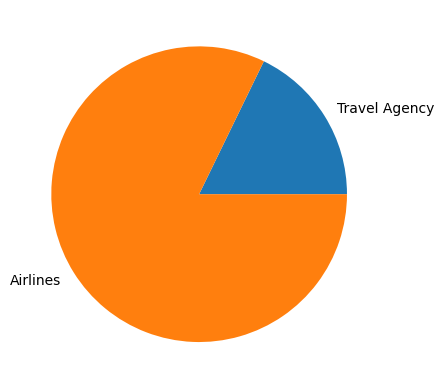

============ Distribution Channel ==================
Offline : 1.5356820234869015%
Online : 1.4625757405294202%


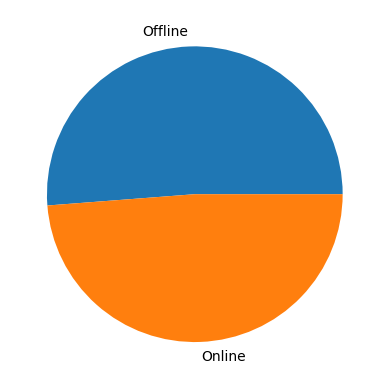

============ Product Name ==================
Comprehensive Plan : 1.3736263736263736%
Rental Vehicle Excess Insurance : 1.0023310023310024%
Value Plan : 0.6998158379373849%
Basic Plan : 0.4205522033278479%
Premier Plan : 1.5463917525773196%
2 way Comprehensive Plan : 1.0791913664690682%
Bronze Plan : 5.186465794023216%
Silver Plan : 6.269453090262339%
Annual Silver Plan : 11.033028812368235%
Cancellation Plan : 0.23617820719269994%
1 way Comprehensive Plan : 0.2701891323926749%
Ticket Protector : 0.6628787878787878%
24 Protect : 0.0%
Gold Plan : 5.113636363636364%
Annual Gold Plan : 10.824742268041238%
Single Trip Travel Protect Silver : 2.312138728323699%
Individual Comprehensive Plan : 4.054054054054054%
Spouse or Parents Comprehensive Plan : 6.666666666666667%
Annual Travel Protect Silver : 4.651162790697675%
Single Trip Travel Protect Platinum : 6.8493150684931505%
Annual Travel Protect Gold : 10.0%
Single Trip Travel Protect Gold : 4.901960784313726%
Annual Travel Protect Platinum

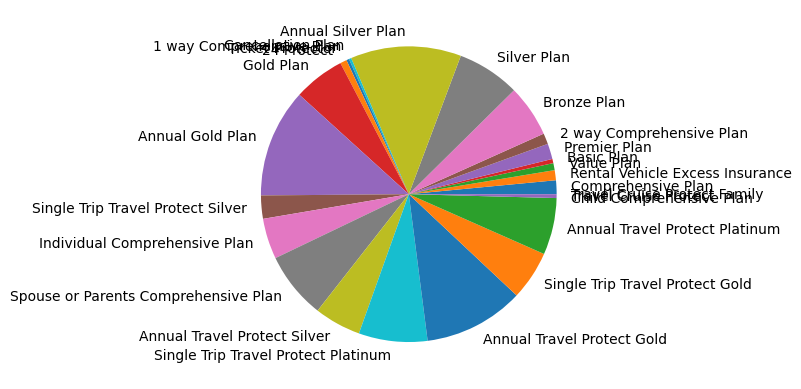

============ Destination ==================
MALAYSIA : 0.387858347386172%
AUSTRALIA : 1.028695181375203%
ITALY : 1.9780219780219779%
UNITED STATES : 1.4624505928853755%
THAILAND : 0.5768578215134035%
KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF : 0.0%
NORWAY : 0.6097560975609756%
VIET NAM : 0.7189934092270821%
DENMARK : 0.0%
SINGAPORE : 4.239909468125235%
JAPAN : 0.6792819019893256%
UNITED KINGDOM : 1.2223071046600458%
INDONESIA : 0.4345307068366165%
INDIA : 0.3553976010661928%
CHINA : 0.9591326105087573%
FRANCE : 1.6563146997929608%
TAIWAN, PROVINCE OF CHINA : 0.5504587155963303%
PHILIPPINES : 0.321285140562249%
MYANMAR : 0.12406947890818859%
HONG KONG : 0.6221484861053505%
KOREA, REPUBLIC OF : 1.0141987829614605%
UNITED ARAB EMIRATES : 0.6993006993006993%
NAMIBIA : 0.0%
NEW ZEALAND : 0.74487895716946%
COSTA RICA : 14.285714285714285%
BRUNEI DARUSSALAM : 0.2564102564102564%
POLAND : 0.0%
SPAIN : 1.483679525222552%
CZECH REPUBLIC : 2.898550724637681%
GERMANY : 1.0964912280701753%
SRI LANKA :

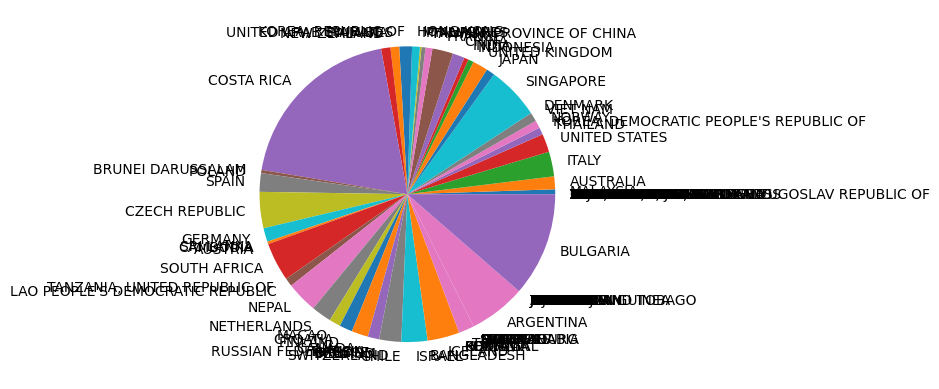

----------------- после ----------------------------
============ Agency ==================
C2B : 81.76382660687594%
EPX : 27.54237288135593%
CWT : 41.14832535885167%
JZI : 22.142857142857142%
KML : 57.14285714285714%
TTW : 80.0%
LWC : 81.81818181818183%
SSI : 33.33333333333333%
RAB : 14.285714285714285%
JWT : 30.76923076923077%
CBH : 100.0%
ART : 16.666666666666664%
TST : 20.0%
CCR : 60.0%
CSR : 50.0%


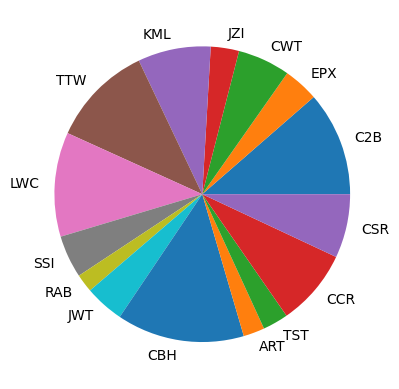

============ Agency Type ==================
Airlines : 69.04205607476635%
Travel Agency : 33.66733466933868%


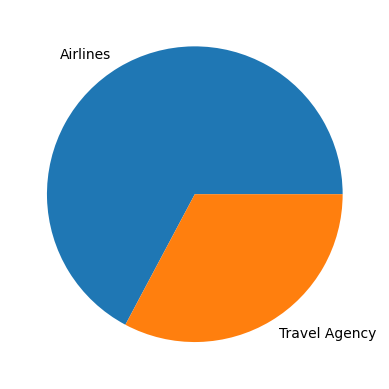

============ Distribution Channel ==================
Online : 49.86301369863014%
Offline : 58.620689655172406%


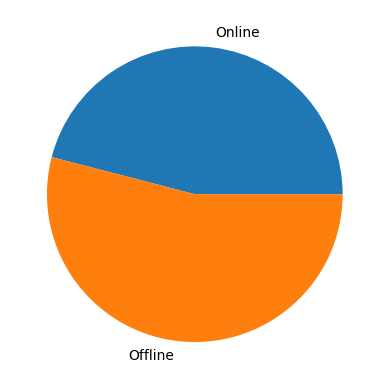

============ Product Name ==================
Bronze Plan : 76.92307692307693%
Annual Silver Plan : 91.27906976744185%
2 way Comprehensive Plan : 44.65408805031446%
Rental Vehicle Excess Insurance : 41.14832535885167%
Silver Plan : 79.66101694915254%
Gold Plan : 72.0%
Cancellation Plan : 13.580246913580247%
Value Plan : 37.254901960784316%
Individual Comprehensive Plan : 75.0%
Annual Gold Plan : 95.45454545454545%
Single Trip Travel Protect Gold : 83.33333333333334%
Premier Plan : 50.0%
Annual Travel Protect Gold : 100.0%
Basic Plan : 18.852459016393443%
Annual Travel Protect Silver : 57.14285714285714%
Ticket Protector : 33.33333333333333%
Annual Travel Protect Platinum : 75.0%
1 way Comprehensive Plan : 13.636363636363635%
Single Trip Travel Protect Platinum : 100.0%
Single Trip Travel Protect Silver : 66.66666666666666%
Spouse or Parents Comprehensive Plan : 100.0%
Comprehensive Plan : 62.5%
Travel Cruise Protect : 20.0%
24 Protect : 0.0%


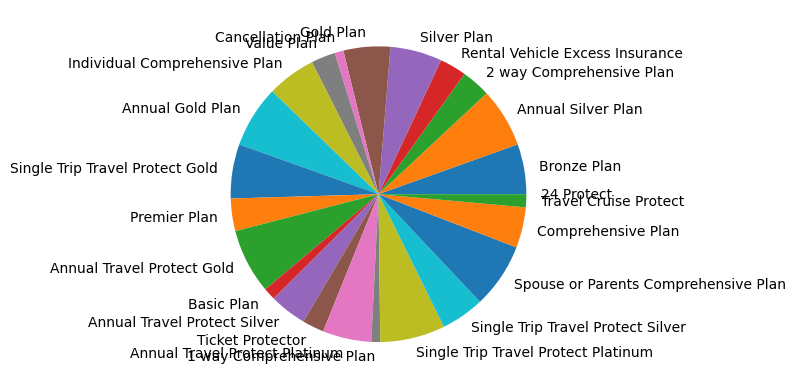

============ Destination ==================
SINGAPORE : 75.1336898395722%
LAO PEOPLE'S DEMOCRATIC REPUBLIC : 25.0%
THAILAND : 28.09917355371901%
AUSTRALIA : 42.22222222222222%
VIET NAM : 40.0%
CHINA : 38.333333333333336%
UNITED STATES : 47.43589743589743%
GERMANY : 38.46153846153847%
PHILIPPINES : 14.814814814814813%
HONG KONG : 31.914893617021278%
INDONESIA : 21.428571428571427%
INDIA : 19.51219512195122%
JAPAN : 36.84210526315789%
UNITED KINGDOM : 55.172413793103445%
SWITZERLAND : 55.55555555555556%
FRANCE : 44.44444444444444%
NEPAL : 50.0%
NETHERLANDS : 60.0%
ITALY : 69.23076923076923%
CAMBODIA : 6.666666666666667%
BRUNEI DARUSSALAM : 25.0%
MALAYSIA : 18.852459016393443%
KOREA, REPUBLIC OF : 46.875%
NEW ZEALAND : 57.14285714285714%
SOUTH AFRICA : 83.33333333333334%
CANADA : 50.0%
TAIWAN, PROVINCE OF CHINA : 28.57142857142857%
BULGARIA : 50.0%
CZECH REPUBLIC : 66.66666666666666%
TURKEY : 50.0%
UNITED ARAB EMIRATES : 40.0%
NORWAY : 50.0%
ICELAND : 42.857142857142854%
SPAIN : 41.666666

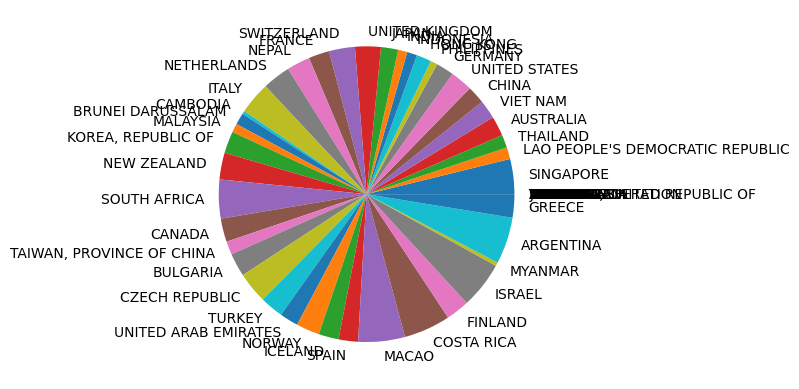

-----------------------------------------------------------------------
True: 927
False: 927
True/C: 50.0%
False/C: 50.0%
True/False: 100.0%


In [ ]:
print('до')

show_all()

n = 61472

df = df.sample(frac=1, random_state=123) # на вcякий случай перемешаем порядок строк
#df[df['Claim'] == 'No'] = df[df['Claim'] == 'No'].reset_index(drop = True)


df = df.drop(df[df['Claim'] == 'No'].head(n).index)

print("----------------- после ----------------------------")
show_all()


print("-----------------------------------------------------------------------")

C = len(df['Claim'])
print(f'True: {len(df[df["Claim"] == "Yes"])}')
print(f"False: {len(df[df['Claim'] == 'No'])}")
print(f'True/C: {100*len(df[df["Claim"] == "Yes"])/C}%')
print(f"False/C: {100*len(df[df['Claim'] == 'No'])/C}%")
print(f"True/False: {100*len(df[df['Claim'] == 'Yes'])/len(df[df['Claim'] == 'No'])}%")

Как и стоило ожидать, после установления балланса между yes и no, данные стали более равномерны по отношениию к claim, хотя и не полностью, значени категориальных признаков все еще можно упорядочить

##### Применяю Функции 

Перед подготовкой данных нужно понять, а сколько различных значений у каждого признака есть

###### Фильтруем признаки

In [ ]:
df.select_dtypes("object").nunique()

Agency                  15
Agency Type              2
Distribution Channel     2
Product Name            24
Claim                    2
Destination             64
dtype: int64

Будет размуно посмотреть как связаны категориальные признаки и Claim

In [ ]:
def get_claim_info(value_name, print_info = True): # показывает долю страховых выплат по каждому значению категориального параметра
    global df
    VU = df[value_name].unique()
    HH = {}
    for v in VU:
        s = len(df[(df[value_name] == v) & (df['Claim'] == 'Yes')])/len(df[df[value_name]==v])
        if print_info:print(f"{v} : {100*s}%")
        HH[v] = s

    return HH

def show_all(print_info = True):
    q = list(df.dtypes[df.dtypes == "object"].keys())
    q.remove('Claim')
    for g in q:
        print(f"============ {g} ==================")
        HH = get_claim_info(g)
        plt.pie(HH.values(), labels = HH.keys())
        plt.show()

============ Agency ==================
C2B : 81.76382660687594%
EPX : 27.54237288135593%
CWT : 41.14832535885167%
JZI : 22.142857142857142%
KML : 57.14285714285714%
TTW : 80.0%
LWC : 81.81818181818183%
SSI : 33.33333333333333%
RAB : 14.285714285714285%
JWT : 30.76923076923077%
CBH : 100.0%
ART : 16.666666666666664%
TST : 20.0%
CCR : 60.0%
CSR : 50.0%


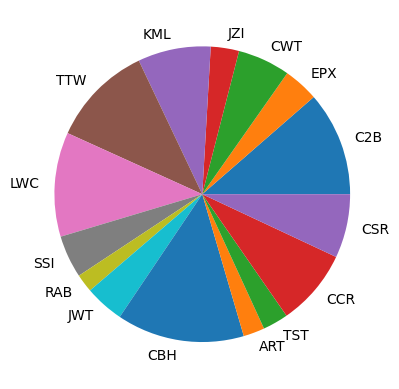

============ Agency Type ==================
Airlines : 69.04205607476635%
Travel Agency : 33.66733466933868%


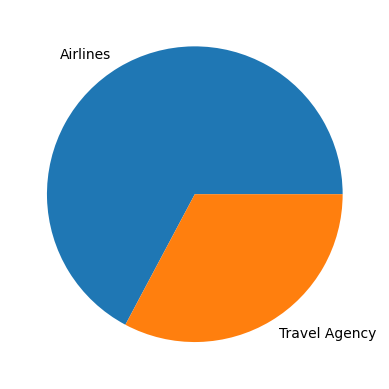

============ Distribution Channel ==================
Online : 49.86301369863014%
Offline : 58.620689655172406%


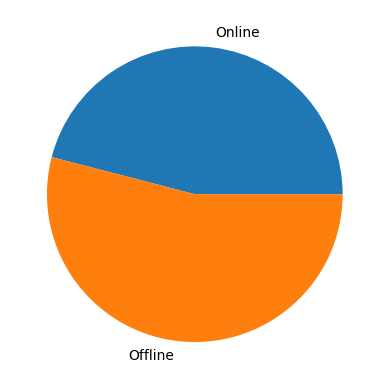

============ Product Name ==================
Bronze Plan : 76.92307692307693%
Annual Silver Plan : 91.27906976744185%
2 way Comprehensive Plan : 44.65408805031446%
Rental Vehicle Excess Insurance : 41.14832535885167%
Silver Plan : 79.66101694915254%
Gold Plan : 72.0%
Cancellation Plan : 13.580246913580247%
Value Plan : 37.254901960784316%
Individual Comprehensive Plan : 75.0%
Annual Gold Plan : 95.45454545454545%
Single Trip Travel Protect Gold : 83.33333333333334%
Premier Plan : 50.0%
Annual Travel Protect Gold : 100.0%
Basic Plan : 18.852459016393443%
Annual Travel Protect Silver : 57.14285714285714%
Ticket Protector : 33.33333333333333%
Annual Travel Protect Platinum : 75.0%
1 way Comprehensive Plan : 13.636363636363635%
Single Trip Travel Protect Platinum : 100.0%
Single Trip Travel Protect Silver : 66.66666666666666%
Spouse or Parents Comprehensive Plan : 100.0%
Comprehensive Plan : 62.5%
Travel Cruise Protect : 20.0%
24 Protect : 0.0%


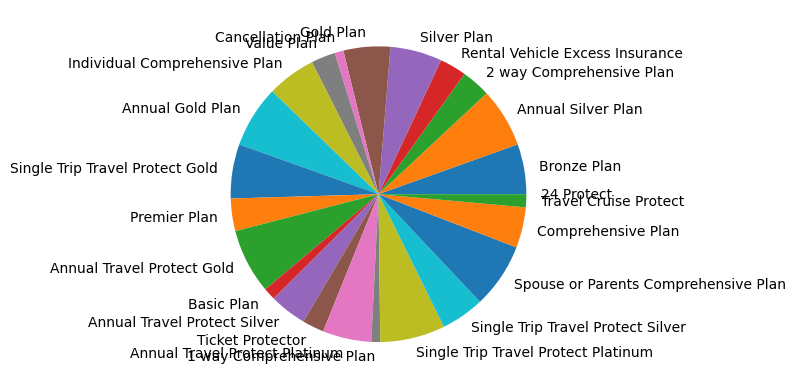

============ Destination ==================
SINGAPORE : 75.1336898395722%
LAO PEOPLE'S DEMOCRATIC REPUBLIC : 25.0%
THAILAND : 28.09917355371901%
AUSTRALIA : 42.22222222222222%
VIET NAM : 40.0%
CHINA : 38.333333333333336%
UNITED STATES : 47.43589743589743%
GERMANY : 38.46153846153847%
PHILIPPINES : 14.814814814814813%
HONG KONG : 31.914893617021278%
INDONESIA : 21.428571428571427%
INDIA : 19.51219512195122%
JAPAN : 36.84210526315789%
UNITED KINGDOM : 55.172413793103445%
SWITZERLAND : 55.55555555555556%
FRANCE : 44.44444444444444%
NEPAL : 50.0%
NETHERLANDS : 60.0%
ITALY : 69.23076923076923%
CAMBODIA : 6.666666666666667%
BRUNEI DARUSSALAM : 25.0%
MALAYSIA : 18.852459016393443%
KOREA, REPUBLIC OF : 46.875%
NEW ZEALAND : 57.14285714285714%
SOUTH AFRICA : 83.33333333333334%
CANADA : 50.0%
TAIWAN, PROVINCE OF CHINA : 28.57142857142857%
BULGARIA : 50.0%
CZECH REPUBLIC : 66.66666666666666%
TURKEY : 50.0%
UNITED ARAB EMIRATES : 40.0%
NORWAY : 50.0%
ICELAND : 42.857142857142854%
SPAIN : 41.666666

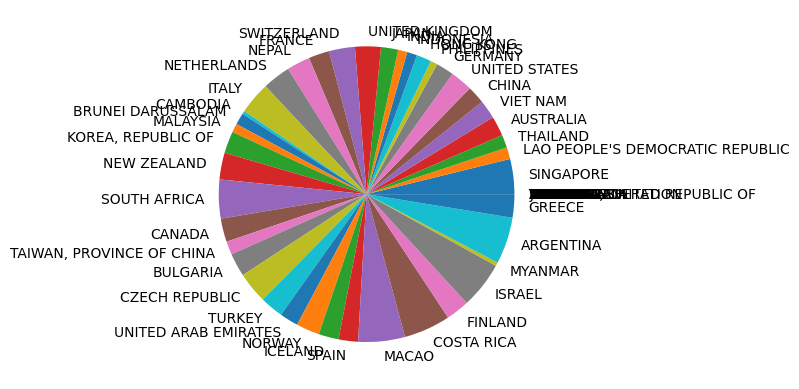

In [ ]:
show_all()


1) Как можно заметить, некоторые категориальные признаки, вроде стран, можно заменить количественными (вероятность того что при путишествии в эту страну придется выплатить страховку)
2) агенства тоже можно заменить на количественый признак
3) страховой план тоже можно заменить количественным признаком
4) Тип агенства можно не менять - нет нужды


In [ ]:
level_map = get_claim_info('Destination', False)
df['Destination'] = df['Destination'].map(level_map)

level_map = get_claim_info('Agency', False)
df['Agency'] = df['Agency'].map(level_map)

level_map = get_claim_info('Product Name', False)
df['Product Name'] = df['Product Name'].map(level_map)

Таким образом получилось учитывать категориальные признаки, но только в том объеме в котором они нам нужны

###### Обработка числовых признаков

Посмотрим на числовые признаки

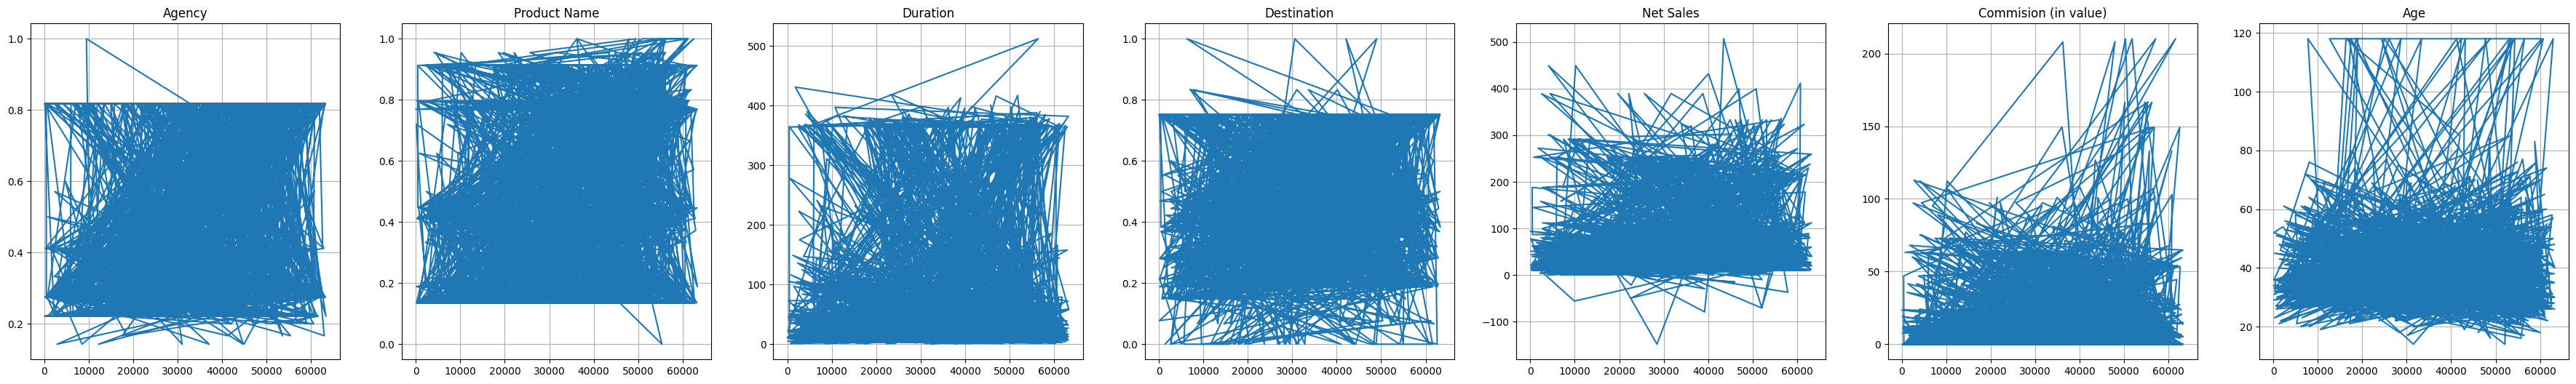

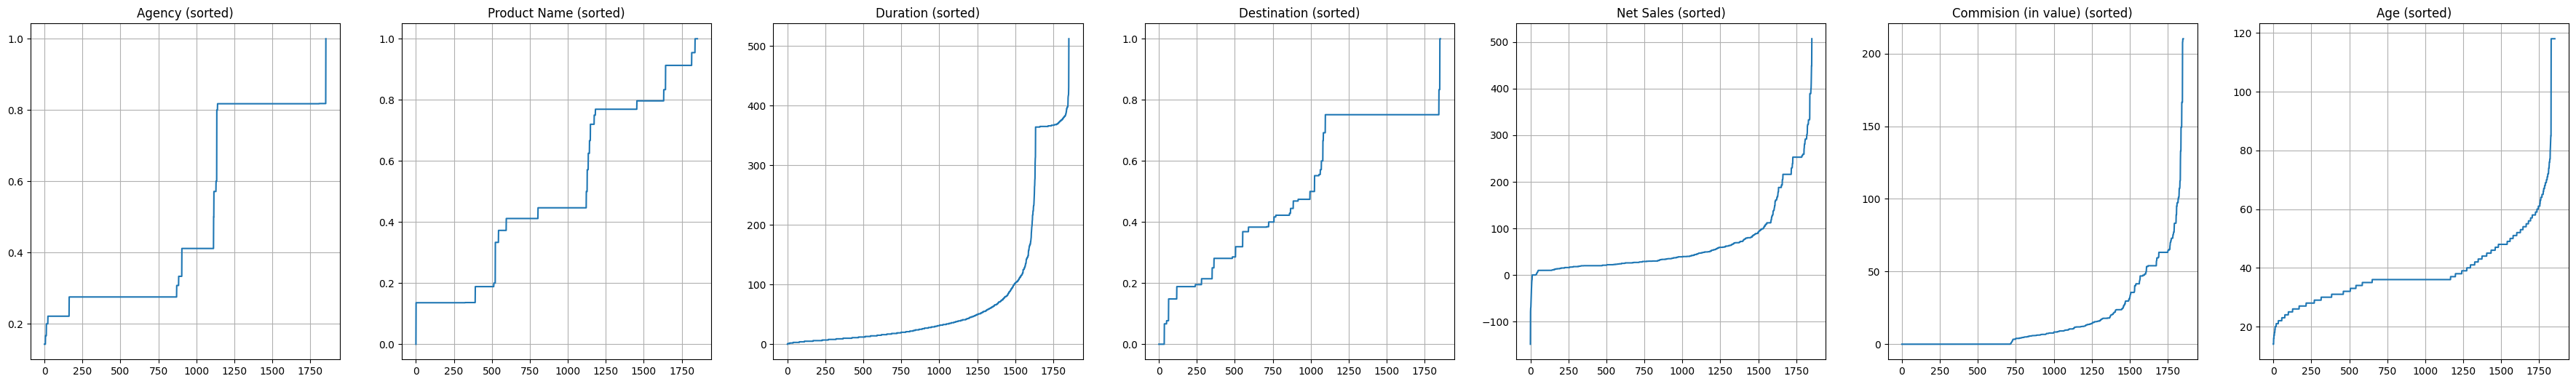

In [ ]:
def show_all_count(key = None):
    q = list(df.dtypes[df.dtypes != "object"].keys())
    c = not (key is None)
    fig, ax = plt.subplots(1, len(q), figsize=(45, 6))
    for n, i in enumerate(q):
        ax[n].plot(key(df[i]) if c else df[i])
        ax[n].set_title(i + (f" ({key.__name__})" if c else ''))
        ax[n].grid(True)
    plt.show()

show_all_count()
show_all_count(sorted) # так же выведем в отсортированном порядке, что бы наглядно увидеть долю выбросов

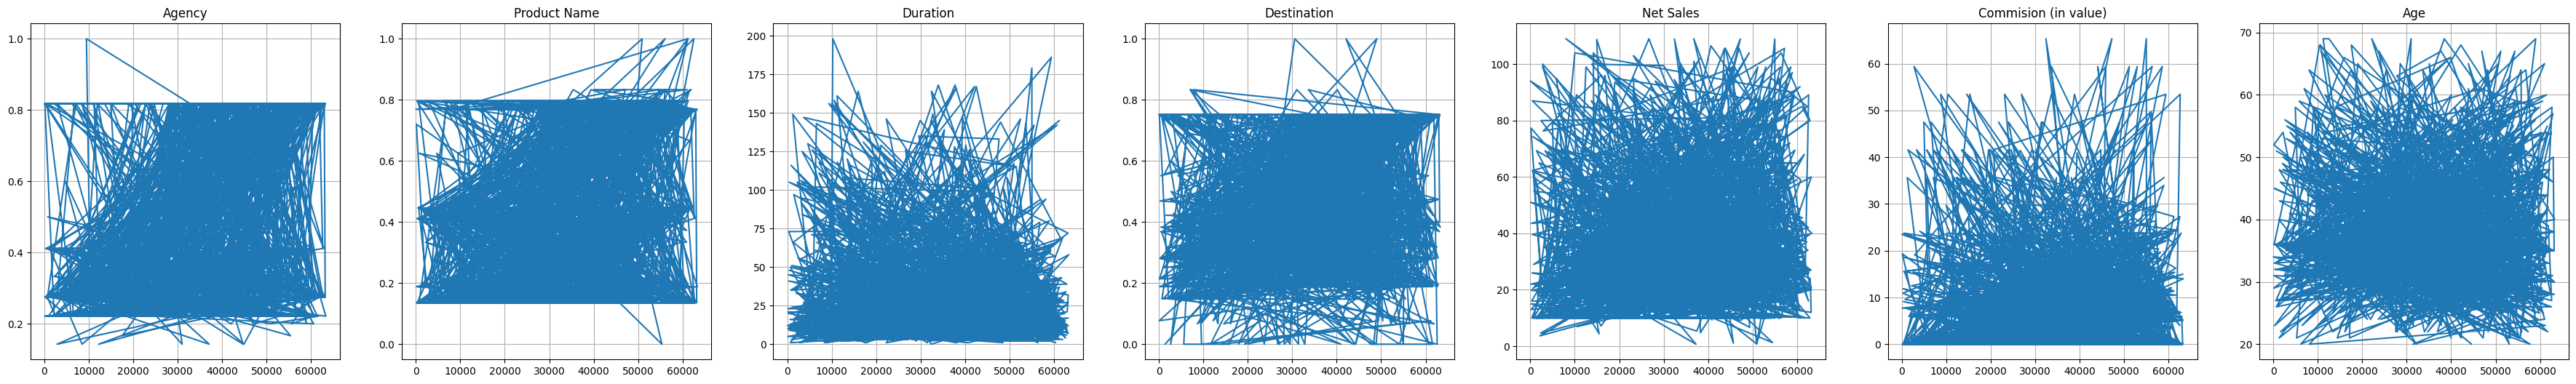

In [ ]:
### убираем очевидные выбросы
df = df[df['Duration'] < 200]
df = df[(df['Net Sales'] < 110) & (df['Net Sales'] > 0)]
df = df[df['Commision (in value)'] < 80]
df = df[(df['Age'] < 70) & (df['Age'] >= 20)]

show_all_count()

##### Конвертирую в numpy массивы

In [ ]:
# теперь можно конвертировать обработаные данные в numpy массив и применить к нему 'написанные функции'

cat_features_mask = (df.dtypes == "object").loc[df.columns != 'Claim'].values
DX = df.loc[:, df.columns != 'Claim'].to_numpy()
X = []
y = np.where(df['Claim'].to_numpy() == 'Yes', 1.0, 0.0)

for n, i in enumerate(cat_features_mask):
    if i:
        X.append(onehot_encoding(DX[:, n]).transpose())
    else:
        X.append(minmax_scale(DX[:, n]))

X = np.vstack(X).transpose()
X = np.matrix(X, dtype=np.float64)
print(X)
print(y)

[[0.78724464 1.         0.         ... 0.36743928 0.1550352  0.06122449]
 [0.15466102 0.         1.         ... 0.18736725 0.         0.32653061]
 [0.31339713 0.         1.         ... 0.45054945 0.45454545 0.2244898 ]
 ...
 [0.15466102 0.         1.         ... 0.22430511 0.         0.32653061]
 [0.09166667 1.         0.         ... 0.23353957 0.1392715  0.30612245]
 [0.15466102 0.         1.         ... 0.08578816 0.         0.32653061]]
[1. 1. 1. ... 0. 0. 0.]


### Применение линейной регрессии (10 баллов)

Это задача классификации, но её можно решить с помощью линейной регрессии, если округлять предсказанный ответ до целого и выбирать ближайший по значению ответ из множества {0, 1}.

Вынесите признак 'Claim' в вектор ответов и разделите датасет на обучающую и тестовую выборку в соотношении 80 к 20. Зафиксируйте random_state.

**Подсказка:** быстро перевести Yes/No в 1/0 можно так - np.where(df['Claim'] == 'Yes', 1,0)

In [ ]:
# разделение на test/train
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=228)

Найдите аналитическое решение для обучающей выборки: обычное и регуляризацией l2. 

In [ ]:
def Q(x): # функция риска
    return x @ x.T

# посчитайте аналитическое решение

class LinearRegression:
    def __init__(self, biases:bool = True) -> None:
        self.biases = biases
        self.w = None
    
    def fit(self, X_train, y_train):
        Xt = X_train
        if self.biases:
            Xt = np.hstack((np.ones((Xt.shape[0], 1)), X_train))
        
        self.w = np.linalg.inv(Xt.transpose() @ Xt) @ Xt.transpose() @ y_train
        self.w = self.w.T

    def calculate(self, x):
        if not self.w is None:
            tx = np.hstack([np.ones((x.shape[0], 1)), x]) if self.biases else x
            return np.array((tx @ self.w).T)
        

Lr = LinearRegression()
Lr.fit(X_train, y_train)
o = Lr.calculate(X_test)

In [ ]:
Lr.w # значение весов

matrix([[ 9.65614505e+10],
        [ 4.82075157e+00],
        [-9.65614505e+10],
        [-9.65614505e+10],
        [-6.12532354e+00],
        [-7.43040941e+00],
        [ 6.80030829e-01],
        [ 7.73857368e-02],
        [ 4.02924633e-01],
        [ 1.44926344e-01],
        [ 1.51203724e-01],
        [-7.23456099e-02]])

In [ ]:
o # значение выхода

array([[-2.48175049, -0.85149457, -2.16134644, -1.2844696 , -2.56246948,
        -0.72687465, -1.6149292 , -2.56008911, -1.55627441, -2.23582458,
        -0.87948603, -1.41181946, -2.50201416, -2.37957764, -2.20050049,
        -0.87254397, -0.88763467, -0.8569855 , -3.95357265, -4.55487318,
        -0.82918799, -0.92502344, -0.85543252, -2.58328247, -2.5552063 ,
        -2.1907196 , -1.23454285, -2.33816528, -1.56253052, -2.33699036,
        -0.90036694, -0.85959753, -0.84422494, -3.93305334, -2.49995422,
        -4.77698949, -0.72144614, -2.59997559, -2.03323364, -1.27836609,
        -2.56126404, -0.85814317, -4.76448319, -0.77041179, -0.92612935,
        -3.92456599, -0.85629719, -2.53433228, -2.47814941, -2.48301697,
        -2.33816528, -2.40557861, -4.60063137, -0.89036336, -0.77423066,
        -1.33239746, -5.21383528, -0.77388563, -2.21774292, -2.29191589,
        -0.88203961, -0.86375985, -2.29655457, -0.77544947, -0.78424975,
        -2.30992126, -0.75495077, -4.69298494, -0.8

In [ ]:
Q(o - y_test)/len(y_test) # MSE

array([[7.47066049]])

In [ ]:
Q(np.round(o) - y_test)/len(y_test) # MSE с округлеными ответами

array([[7.64583333]])

In [ ]:
# посчитать аналитическое решение с регуляризацией

class LinearRegressionWithRegularization:
    def __init__(self, biases:bool = True) -> None:
        self.biases = biases
        self.w = None
    
    def fit(self, X_train, y_train, _lambda = 1):
        Xt = X_train
        if self.biases:
            Xt = np.hstack((np.ones((Xt.shape[0], 1)), X_train))
        
        I = np.eye(X.shape[1] + 1) if self.biases else np.eye(X.shape[1])
        self.w = np.linalg.inv(Xt.transpose() @ Xt + _lambda**2 * I) @ Xt.transpose() @ y_train
        self.w = self.w.transpose()

    def calculate(self, x):
        if not self.w is None:
            tx = np.hstack([np.ones((x.shape[0], 1)), x]) if self.biases else x
            return np.array((tx @ self.w).T)


Lr = LinearRegressionWithRegularization()
Lr.fit(X_train, y_train)
o = Lr.calculate(X_test)

In [ ]:
Lr.w # значение весов

matrix([[-0.01160038],
        [ 0.04947234],
        [-0.01242799],
        [ 0.00082761],
        [ 0.07153722],
        [-0.0831376 ],
        [ 0.63366001],
        [ 0.07829746],
        [ 0.38619915],
        [ 0.15342711],
        [ 0.14223906],
        [-0.07110342]])

In [ ]:
o # значение выхода

array([[0.14331765, 0.77046503, 0.45528083, 0.569012  , 0.06757947,
        0.89584532, 0.24283273, 0.06928186, 0.30123471, 0.3758179 ,
        0.74110181, 0.4417267 , 0.12613258, 0.25007474, 0.41474704,
        0.74841688, 0.73327327, 0.76272679, 0.38321572, 0.40780476,
        0.79124938, 0.6964699 , 0.76464826, 0.04568739, 0.07390331,
        0.42296031, 0.61687868, 0.28069501, 0.29549375, 0.28188134,
        0.71998838, 0.76062619, 0.77723393, 0.40407354, 0.12818692,
        0.19557195, 0.90150877, 0.03051185, 0.57823071, 0.57495044,
        0.06791156, 0.76163881, 0.20784088, 0.85129976, 0.69601709,
        0.41255458, 0.76523318, 0.09333339, 0.15391379, 0.14429675,
        0.28069501, 0.21852882, 0.37496038, 0.73036175, 0.84853843,
        0.52114706, 0.19042567, 0.84799873, 0.39616749, 0.32292285,
        0.73909175, 0.75600087, 0.31667635, 0.84603176, 0.83886361,
        0.30595209, 0.86700081, 0.27353595, 0.72455739, 0.39402179,
        0.86862478, 0.69508483, 0.06966445, 0.72

In [ ]:
Q(o - y_test)/len(y_test) # MSE

array([[0.15232961]])

In [ ]:
Q(np.round(o) - y_test)/len(y_test) # MSE с округлеными ответами

array([[0.20138889]])

Постройте модель LinearRegression, примените к тестовой выборке и посчитайте MSE (можно использовать библиотеку sklearn)

In [ ]:
# обучите модель линейной регрессии LinearRegression на обучающей выборке, примените к тестовой
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(np.array(X_train), np.array(y_train))
o = lr.predict(np.array(X_test))
o


array([0.13910416, 0.77026721, 0.45951378, 0.57176681, 0.05838864,
       0.89489814, 0.24133601, 0.0607838 , 0.29997262, 0.38502276,
       0.7422876 , 0.44442204, 0.11883121, 0.24128032, 0.42035669,
       0.74921791, 0.73412667, 0.76478202, 0.38982948, 0.41740728,
       0.79257691, 0.6967379 , 0.76633019, 0.03757218, 0.06564717,
       0.43014649, 0.62168869, 0.28269181, 0.29373555, 0.28386432,
       0.72140058, 0.7621761 , 0.77754034, 0.41034549, 0.12089985,
       0.19529059, 0.90032665, 0.02089145, 0.58762399, 0.57788959,
       0.0595849 , 0.76362173, 0.20779688, 0.85136316, 0.69563286,
       0.41883845, 0.76546809, 0.08653679, 0.14270318, 0.13784168,
       0.28269181, 0.21527847, 0.37163694, 0.73139667, 0.84753158,
       0.5238529 , 0.1999868 , 0.84788933, 0.40310764, 0.32892748,
       0.73972783, 0.75800768, 0.32429223, 0.84632549, 0.83751425,
       0.31094044, 0.86681668, 0.27929157, 0.72549091, 0.40323828,
       0.86859976, 0.695199  , 0.06217426, 0.7234684 , 0.35136

In [ ]:
# посчитайте MSE, предварительно округлив предсказанные ответы до целого
mean_squared_error(y_test, np.round(o))

0.2013888888888889

### Вывод (1 балла)

Напишите краткий вывод по заданию (достаточно пары предложений). Расскажите, какие способы предобработки данных вы выбрали и почему. Насколько хороша ваша модель?

Я сопоставил категориальным признакам, с большим количествам разных значений - числа, которые косвенно отражают вероятность claim (Так можно сделать т.к если эта выборка достаточно объективна, то страны/агенства/тип страховки можно упорядочить по рейтингу и в этом контексте " значения категории уже не будут линейно независимы" ;) ).
Моя модель хорошая, т.к даже без регулизации MSE достаточно маленькая - думаю это связано с большим количеством независимых друг от друга параметров (возраст с длительность и т.д), а так же с тем, что я сократил количество категориальных признаков до минимума, т.к 1 категориальный признак превращается в множество зависимых друг от друга численых параметров (если объект принадлежит к категори A = (1, 0), то он точно не пренадлежит к категории B = (0, 1))

Минус модели - это в первую очередь факт сильной предобработки данных, т.е если взять произвольные значения для признаков, то их вначале придется привести к виду, который модель поймет (хотя это повышает интерпритируемость модели)

Ляшенков Илья